In [2]:
import pandas as pd
ai_channel = pd.read_csv(r'C:/Users/Atharv/Downloads/RP/CSV/channels.csv')
ai_videos = pd.read_csv(r'C:/Users/Atharv/Downloads/RP/CSV/videos.csv')
human_channel = pd.read_csv(r'C:/Users/Atharv/Downloads/RP/CSV/human_channels.csv')
human_videos = pd.read_csv(r'C:/Users/Atharv/Downloads/RP/CSV/human_videos.csv')


ls = [ai_channel, ai_videos, human_channel, human_videos]

for df in ls:
    print(df.shape)
    print(df.columns)
    print(df.dtypes)
    print()
    print()

(50, 8)
Index(['channel_id', 'channel_name', 'channel_description', 'creation_date',
       'subscribers', 'total_views', 'total_videos', 'uploads_playlist'],
      dtype='object')
channel_id             object
channel_name           object
channel_description    object
creation_date          object
subscribers             int64
total_views             int64
total_videos            int64
uploads_playlist       object
dtype: object


(500, 8)
Index(['channel_id', 'video_id', 'video_title', 'published_date', 'views',
       'likes', 'comments', 'duration'],
      dtype='object')
channel_id        object
video_id          object
video_title       object
published_date    object
views              int64
likes              int64
comments           int64
duration          object
dtype: object


(50, 8)
Index(['channel_id', 'channel_name', 'channel_description', 'creation_date',
       'subscribers', 'total_views', 'total_videos', 'uploads_playlist'],
      dtype='object')
channel_id         

In [3]:
import pandas as pd
import re

# --- Convert dates to datetime ---
for df in [ai_channel, human_channel]:
    df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

for df in [ai_videos, human_videos]:
    df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')

# --- Convert ISO 8601 duration to seconds ---
def iso8601_duration_to_seconds(duration):
    """
    Converts ISO 8601 duration string (PT#H#M#S) to total seconds.
    Example: PT1H26M56S -> 5216 seconds
    """
    if not isinstance(duration, str):
        return 0
    hours = minutes = seconds = 0
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration)
    if match:
        h, m, s = match.groups()
        hours = int(h) if h else 0
        minutes = int(m) if m else 0
        seconds = int(s) if s else 0
    return hours*3600 + minutes*60 + seconds

for df in [ai_videos, human_videos]:
    df['duration_sec'] = df['duration'].apply(iso8601_duration_to_seconds)

# --- Handle missing values ---
for df in [ai_channel, human_channel, ai_videos, human_videos]:
    # Numeric columns: fill missing with 0
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df[num_cols] = df[num_cols].fillna(0)
    
    # Object columns: fill missing with 'Unknown'
    obj_cols = df.select_dtypes(include=['object']).columns
    df[obj_cols] = df[obj_cols].fillna('Unknown')

# --- Reset index (optional) ---
for df in [ai_channel, ai_videos, human_channel, human_videos]:
    df.reset_index(drop=True, inplace=True)

print("Preprocessing complete!")


Preprocessing complete!


In [4]:
# --- Check first few rows and data types ---
for name, df in zip(['AI Channels', 'AI Videos', 'Human Channels', 'Human Videos'],
                    [ai_channel, ai_videos, human_channel, human_videos]):
    print(f"--- {name} ---")
    print(df.head(5))
    
    print("\n")


--- AI Channels ---
                 channel_id   channel_name  \
0  UCiMm5csnl5xQHZ1i9ykueQQ          Glorb   
1  UCJvBXBYPWE1aIlrM0r1Ilhw  Greenskull AI   
2  UCOsNGd3WZ6ojJMsn4sT_aTg    Footiversus   
3  UCgZgbNM5bKHxBkShHnoLGEQ  NeuralNuggets   
4  UCF70EfaG1Iw7FpCbbr6E-wA      ai.shutov   

                                 channel_description  \
0  Glorb. MR Swags. Dankton. Spongeopp.\nemail: g...   
1  Hey! I'm Greenskull! I've been a YouTuber sinc...   
2  ❤️ Welcome to Footiversus! The ultimate destin...   
3  Welcome to Neural Nuggets, a YouTube channel h...   
4  🎥 Binge-worthy AI videos! Creative, fun, and t...   

                     creation_date  subscribers  total_views  total_videos  \
0 2023-06-03 04:28:55.720162+00:00      1020000    316922009           245   
1 2022-07-15 22:09:52.427180+00:00      2090000   1278417719          1074   
2 2023-04-17 23:42:38.714622+00:00      3440000    391985921            92   
3 2023-06-01 07:02:10.393079+00:00       981000    371

In [5]:
# Merge AI videos with AI channels on 'channel_id'
ai_data = pd.merge(ai_videos, ai_channel, on='channel_id', how='left')
# Avoid division by zero

# Convert to timezone-naive
ai_channel['creation_date'] = ai_channel['creation_date'].dt.tz_localize(None)

# Now compute channel age
from datetime import datetime
ai_channel['channel_age_days'] = (datetime.now() - ai_channel['creation_date']).dt.days

ai_data['engagement_rate'] = ((ai_data['likes'] + ai_data['comments']) / ai_data['views']) * 100
ai_data['like_ratio'] = ai_data['likes'] / ai_data['views']
ai_data['comment_ratio'] = ai_data['comments'] / ai_data['views']

ai_channel_summary = ai_channel[['subscribers', 'total_views', 'total_videos', 'channel_age_days']].describe()
print("AI Channels Summary:\n", ai_channel_summary)

ai_video_summary = ai_data[['views', 'likes', 'comments', 'duration_sec', 'engagement_rate']].describe()
print("AI Videos Summary:\n", ai_video_summary)


AI Channels Summary:
         subscribers   total_views  total_videos  channel_age_days
count  5.000000e+01  5.000000e+01     50.000000         40.000000
mean   4.294558e+05  1.675341e+08    369.280000        632.375000
std    7.879696e+05  2.536147e+08    771.919527        519.401168
min    3.020000e+03  1.205970e+06     13.000000         75.000000
25%    4.412500e+04  1.292120e+07     63.500000        268.000000
50%    1.180000e+05  7.646340e+07    155.000000        399.500000
75%    3.360000e+05  2.398571e+08    271.250000        922.500000
max    3.650000e+06  1.278418e+09   4703.000000       2188.000000
AI Videos Summary:
               views         likes    comments  duration_sec  engagement_rate
count  5.000000e+02  5.000000e+02   500.00000    500.000000       500.000000
mean   5.871447e+05  8.295660e+03    88.76400    158.048000         1.988942
std    4.069773e+06  6.317459e+04   435.19106    657.138756         2.773032
min    1.700000e+01  0.000000e+00     0.00000      4.000

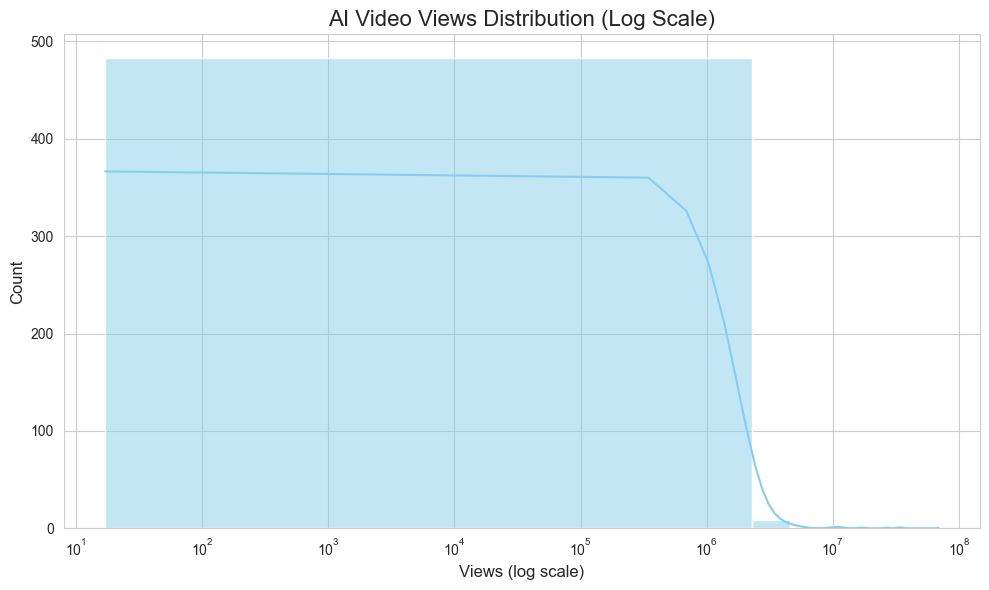

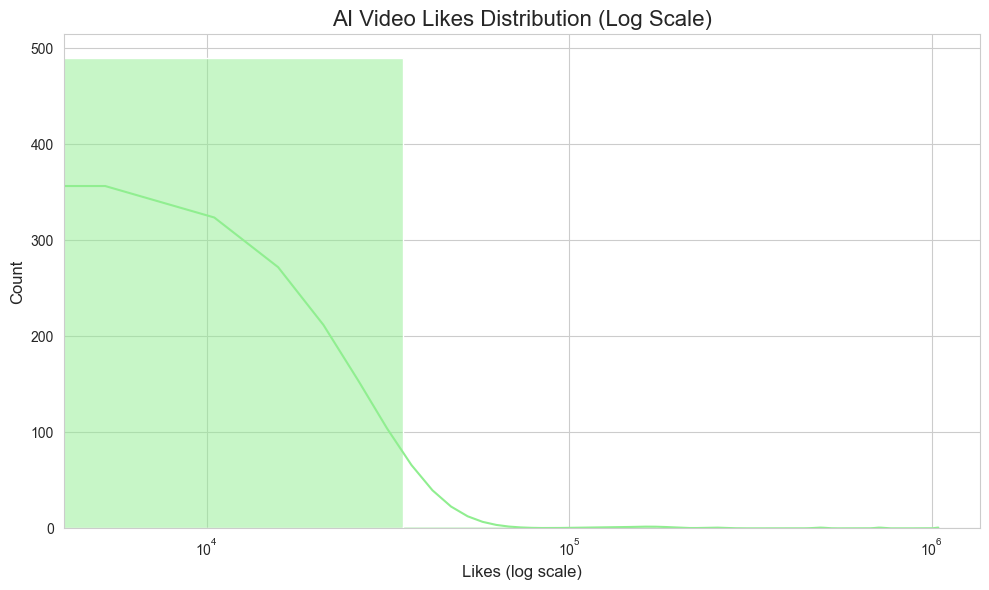

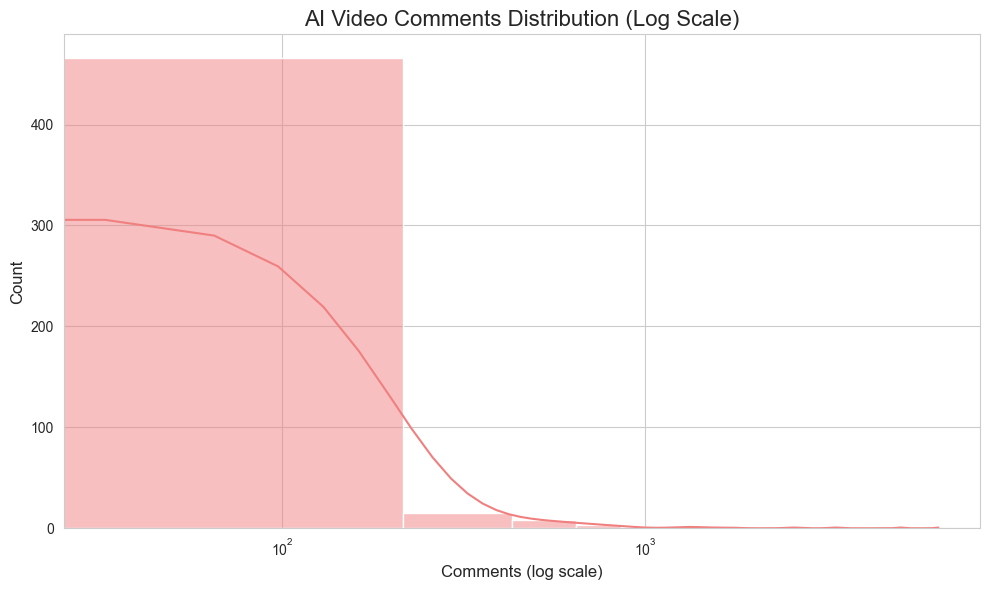

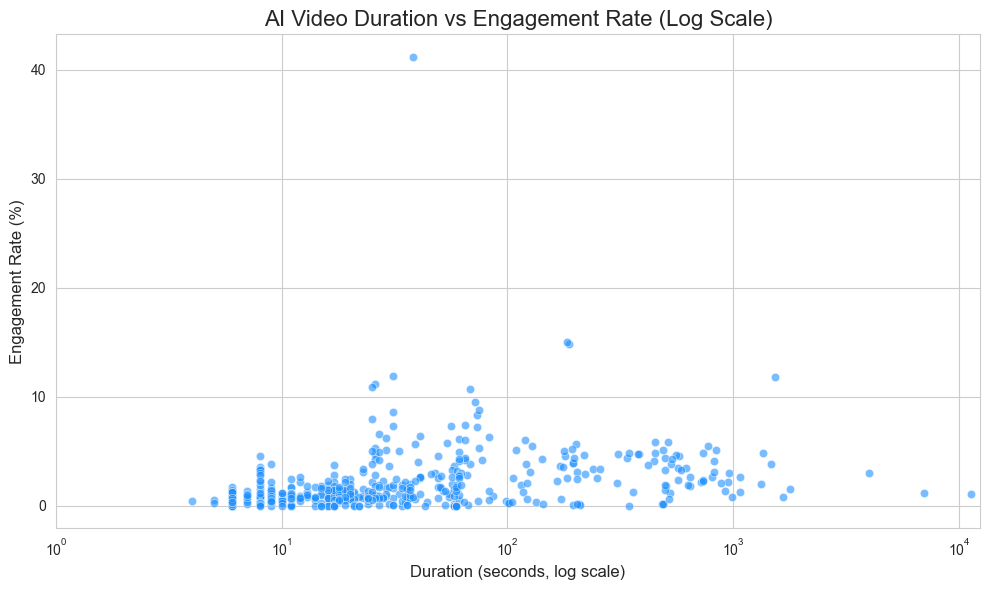

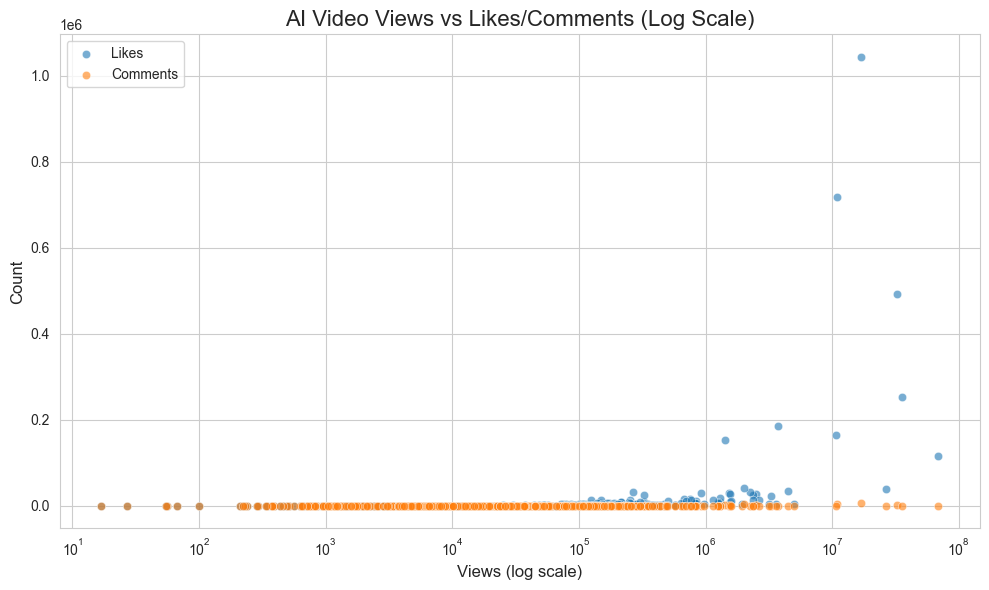

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- 1. Views Distribution (log scale) ---
plt.figure(figsize=(10,6))
sns.histplot(ai_data['views'], bins=30, kde=True, color='skyblue')
plt.xscale('log')  # log scale for x-axis
plt.title("AI Video Views Distribution (Log Scale)", fontsize=16)
plt.xlabel("Views (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Likes Distribution (log scale) ---
plt.figure(figsize=(10,6))
sns.histplot(ai_data['likes'], bins=30, kde=True, color='lightgreen')
plt.xscale('log')
plt.title("AI Video Likes Distribution (Log Scale)", fontsize=16)
plt.xlabel("Likes (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# --- 3. Comments Distribution (log scale) ---
plt.figure(figsize=(10,6))
sns.histplot(ai_data['comments'], bins=30, kde=True, color='lightcoral')
plt.xscale('log')
plt.title("AI Video Comments Distribution (Log Scale)", fontsize=16)
plt.xlabel("Comments (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# --- 4. Duration vs Engagement (log scale for duration) ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=ai_data, 
    x='duration_sec', 
    y='engagement_rate', 
    alpha=0.6,
    color='dodgerblue'
)

# Log scale for x-axis
plt.xscale('log')

# Optional: set min and max limits for better readability
plt.xlim(1, ai_data['duration_sec'].max()*1.1)  # avoid 0 value in log scale

plt.title("AI Video Duration vs Engagement Rate (Log Scale)", fontsize=16)
plt.xlabel("Duration (seconds, log scale)", fontsize=12)
plt.ylabel("Engagement Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()



# --- 5. Views vs Likes/Comments (log scale for views) ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=ai_data, x='views', y='likes', label='Likes', alpha=0.6)
sns.scatterplot(data=ai_data, x='views', y='comments', label='Comments', alpha=0.6)
plt.xscale('log')  # log scale for views
plt.title("AI Video Views vs Likes/Comments (Log Scale)", fontsize=16)
plt.xlabel("Views (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


Human Channels Summary:
         subscribers   total_views  total_videos  channel_age_days
count  5.000000e+01  5.000000e+01     50.000000         29.000000
mean   4.348780e+05  1.887218e+08   3560.540000       3602.551724
std    8.224690e+05  4.596475e+08  13226.245587        965.038326
min    2.740000e+03  0.000000e+00      0.000000       2269.000000
25%    4.160000e+04  6.747781e+06    139.000000       3064.000000
50%    1.210000e+05  1.417618e+07    328.500000       3481.000000
75%    3.645000e+05  1.314140e+08    689.250000       3930.000000
max    4.370000e+06  2.639301e+09  81799.000000       7033.000000
Human Videos Summary:
               views          likes     comments  duration_sec  engagement_rate
count  4.900000e+02     490.000000   490.000000    490.000000       487.000000
mean   7.474132e+04    1714.683673   133.422449   1405.244898         3.092400
std    4.050166e+05    7506.076674   584.811234   2408.631151         2.762848
min    0.000000e+00       0.000000     0.0

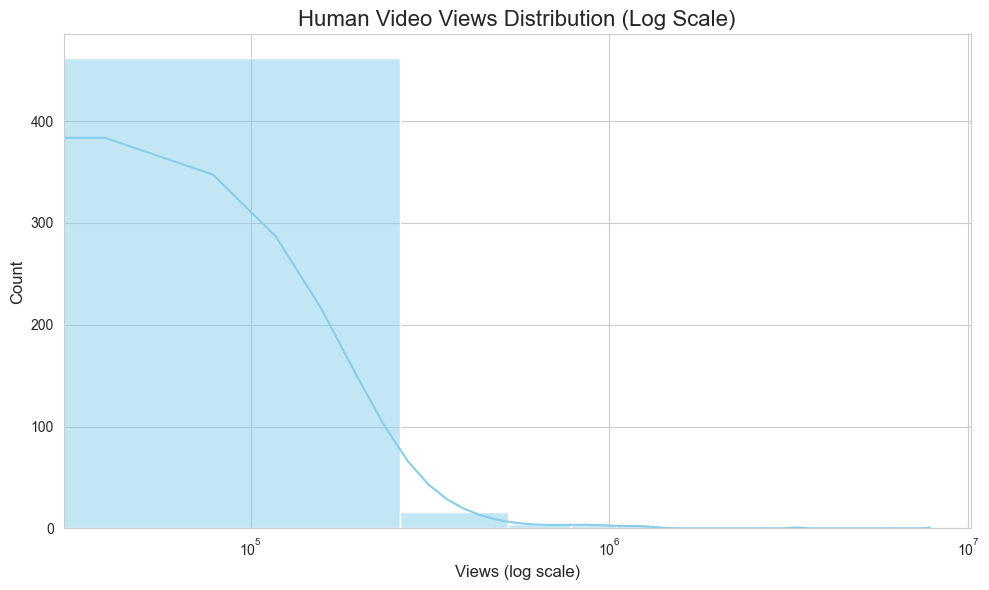

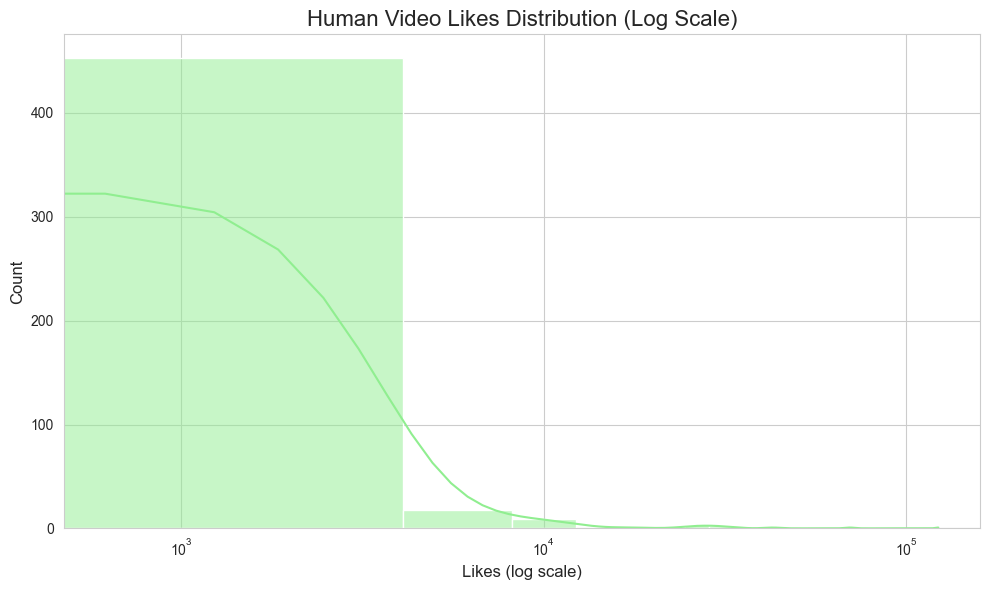

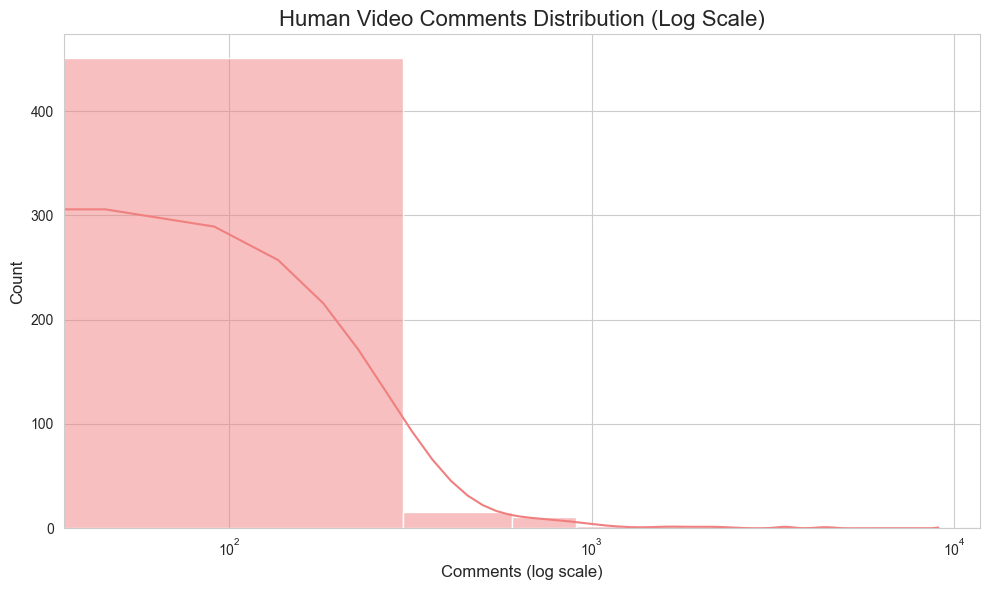

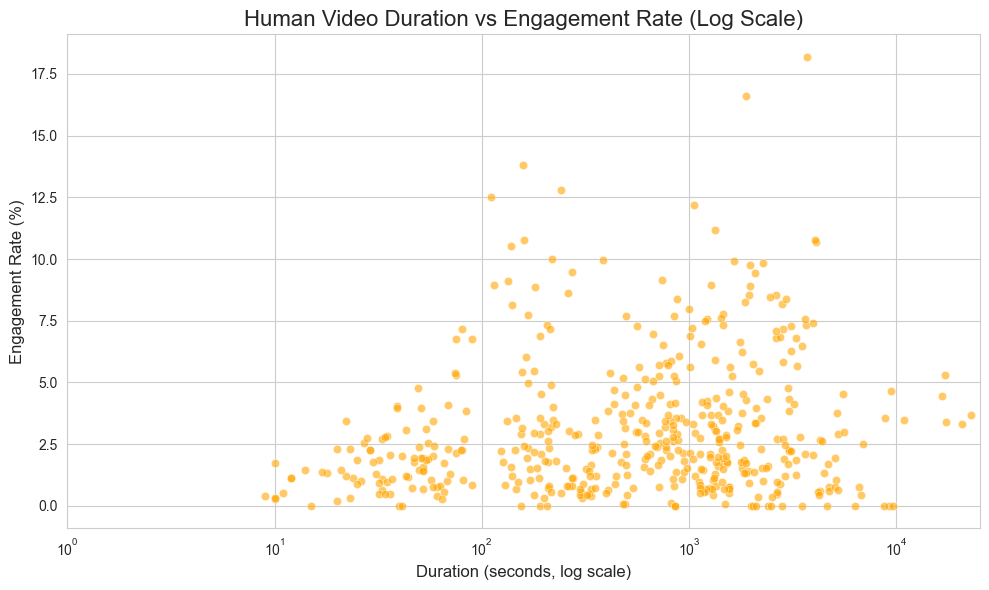

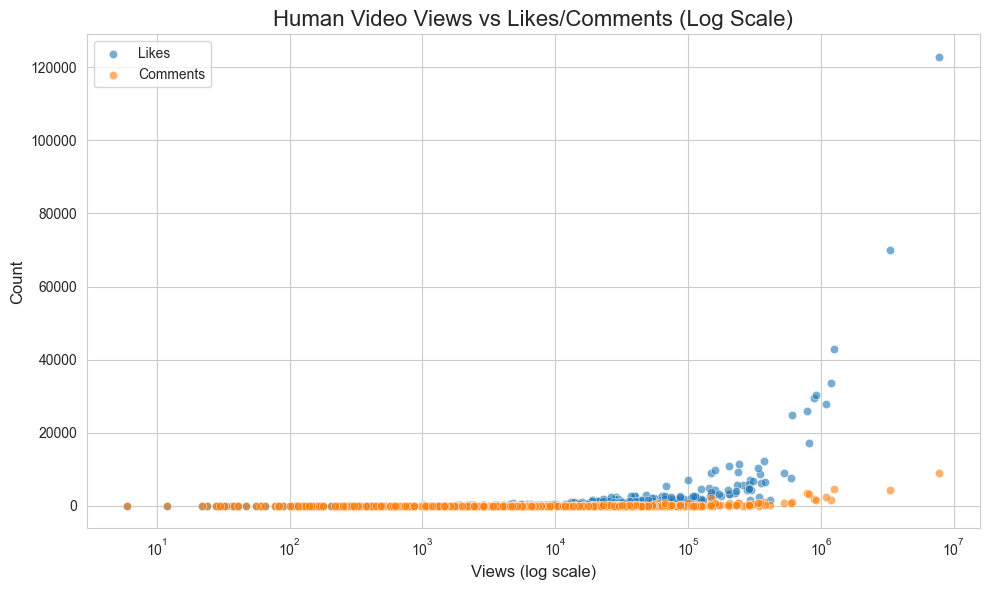

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")

# --- 1. Merge Human Videos with Channels ---
human_data = pd.merge(human_videos, human_channel, on='channel_id', how='left')

# --- 2. Ensure timezone-naive for channel creation date ---
human_channel['creation_date'] = human_channel['creation_date'].dt.tz_localize(None)

# --- 3. Compute channel age in days ---
human_channel['channel_age_days'] = (datetime.now() - human_channel['creation_date']).dt.days

# --- 4. Engagement metrics for videos ---
human_data['engagement_rate'] = ((human_data['likes'] + human_data['comments']) / human_data['views']) * 100
human_data['like_ratio'] = human_data['likes'] / human_data['views']
human_data['comment_ratio'] = human_data['comments'] / human_data['views']

# --- 5. Human Channel Summary ---
human_channel_summary = human_channel[['subscribers', 'total_views', 'total_videos', 'channel_age_days']].describe()
print("Human Channels Summary:\n", human_channel_summary)

# --- 6. Human Video Summary ---
human_video_summary = human_data[['views', 'likes', 'comments', 'duration_sec', 'engagement_rate']].describe()
print("Human Videos Summary:\n", human_video_summary)

# --- 7. Views Distribution (log scale) ---
plt.figure(figsize=(10,6))
sns.histplot(human_data['views'], bins=30, kde=True, color='skyblue')
plt.xscale('log')
plt.title("Human Video Views Distribution (Log Scale)", fontsize=16)
plt.xlabel("Views (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# --- 8. Likes Distribution (log scale) ---
plt.figure(figsize=(10,6))
sns.histplot(human_data['likes'], bins=30, kde=True, color='lightgreen')
plt.xscale('log')
plt.title("Human Video Likes Distribution (Log Scale)", fontsize=16)
plt.xlabel("Likes (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# --- 9. Comments Distribution (log scale) ---
plt.figure(figsize=(10,6))
sns.histplot(human_data['comments'], bins=30, kde=True, color='lightcoral')
plt.xscale('log')
plt.title("Human Video Comments Distribution (Log Scale)", fontsize=16)
plt.xlabel("Comments (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# --- 10. Duration vs Engagement (log scale for duration) ---
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=human_data,
    x='duration_sec',
    y='engagement_rate',
    alpha=0.6,
    color='orange'
)
plt.xscale('log')
plt.xlim(1, human_data['duration_sec'].max()*1.1)
plt.title("Human Video Duration vs Engagement Rate (Log Scale)", fontsize=16)
plt.xlabel("Duration (seconds, log scale)", fontsize=12)
plt.ylabel("Engagement Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()

# --- 11. Views vs Likes/Comments (log scale for views) ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=human_data, x='views', y='likes', label='Likes', alpha=0.6)
sns.scatterplot(data=human_data, x='views', y='comments', label='Comments', alpha=0.6)
plt.xscale('log')
plt.title("Human Video Views vs Likes/Comments (Log Scale)", fontsize=16)
plt.xlabel("Views (log scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


=== Channel-level Comparison ===

AI Channels Summary:
        subscribers   total_views  total_videos  channel_age_days
count  5.000000e+01  5.000000e+01     50.000000         40.000000
mean   4.294558e+05  1.675341e+08    369.280000        632.375000
std    7.879696e+05  2.536147e+08    771.919527        519.401168
min    3.020000e+03  1.205970e+06     13.000000         75.000000
25%    4.412500e+04  1.292120e+07     63.500000        268.000000
50%    1.180000e+05  7.646340e+07    155.000000        399.500000
75%    3.360000e+05  2.398571e+08    271.250000        922.500000
max    3.650000e+06  1.278418e+09   4703.000000       2188.000000

Human Channels Summary:
        subscribers   total_views  total_videos  channel_age_days
count  5.000000e+01  5.000000e+01     50.000000         29.000000
mean   4.348780e+05  1.887218e+08   3560.540000       3602.551724
std    8.224690e+05  4.596475e+08  13226.245587        965.038326
min    2.740000e+03  0.000000e+00      0.000000       2269.000

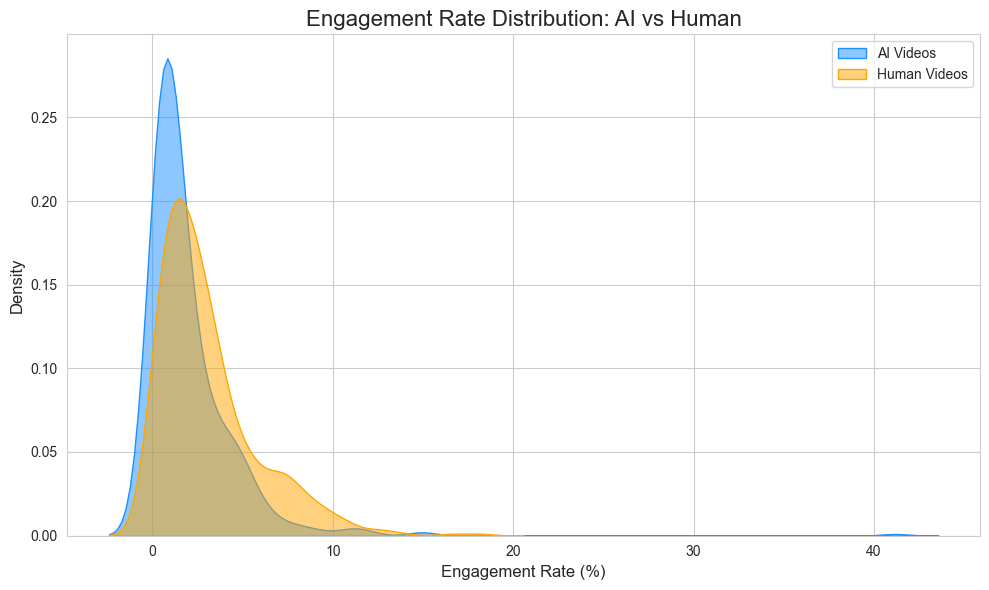

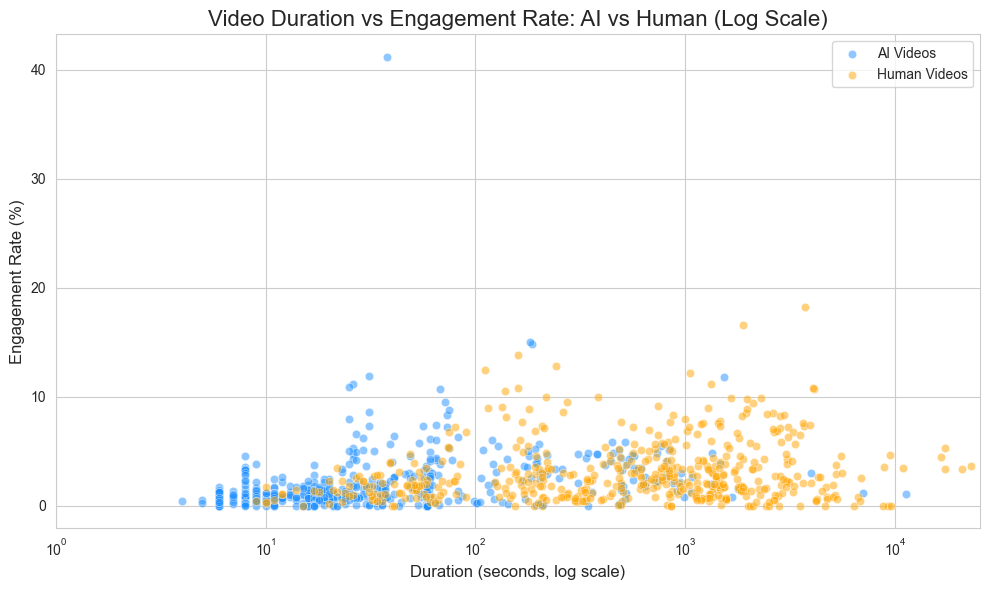

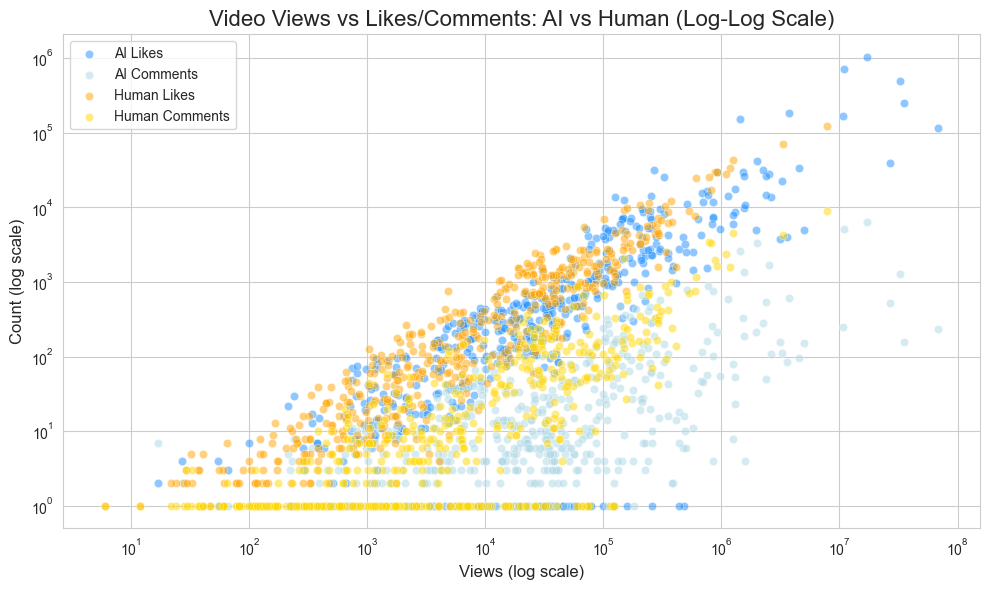

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- 1. Channel-level comparison ---
channel_metrics = ['subscribers', 'total_views', 'total_videos', 'channel_age_days']

print("=== Channel-level Comparison ===")
print("\nAI Channels Summary:")
print(ai_channel[channel_metrics].describe())
print("\nHuman Channels Summary:")
print(human_channel[channel_metrics].describe())

# --- 2. Video-level comparison ---
video_metrics = ['views', 'likes', 'comments', 'duration_sec', 'engagement_rate']

print("\n=== Video-level Comparison ===")
print("\nAI Videos Summary:")
print(ai_data[video_metrics].describe())
print("\nHuman Videos Summary:")
print(human_data[video_metrics].describe())

# --- 3. Engagement Rate Distribution (log scale for clarity) ---
plt.figure(figsize=(10,6))
sns.kdeplot(ai_data['engagement_rate'], label='AI Videos', fill=True, color='dodgerblue', alpha=0.5)
sns.kdeplot(human_data['engagement_rate'], label='Human Videos', fill=True, color='orange', alpha=0.5)
plt.title("Engagement Rate Distribution: AI vs Human", fontsize=16)
plt.xlabel("Engagement Rate (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# --- 4. Duration vs Engagement comparison (log scale) ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=ai_data, x='duration_sec', y='engagement_rate', alpha=0.5, label='AI Videos', color='dodgerblue')
sns.scatterplot(data=human_data, x='duration_sec', y='engagement_rate', alpha=0.5, label='Human Videos', color='orange')
plt.xscale('log')
plt.xlim(1, max(ai_data['duration_sec'].max(), human_data['duration_sec'].max())*1.1)
plt.title("Video Duration vs Engagement Rate: AI vs Human (Log Scale)", fontsize=16)
plt.xlabel("Duration (seconds, log scale)", fontsize=12)
plt.ylabel("Engagement Rate (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# --- 5. Views vs Likes/Comments comparison (log scale for views) ---
plt.figure(figsize=(10,6))
sns.scatterplot(data=ai_data, x='views', y=ai_data['likes']+1, alpha=0.5, label='AI Likes', color='dodgerblue')
sns.scatterplot(data=ai_data, x='views', y=ai_data['comments']+1, alpha=0.5, label='AI Comments', color='lightblue')
sns.scatterplot(data=human_data, x='views', y=human_data['likes']+1, alpha=0.5, label='Human Likes', color='orange')
sns.scatterplot(data=human_data, x='views', y=human_data['comments']+1, alpha=0.5, label='Human Comments', color='gold')
plt.xscale('log')
plt.yscale('log')  # now y-axis is also log scale
plt.title("Video Views vs Likes/Comments: AI vs Human (Log-Log Scale)", fontsize=16)
plt.xlabel("Views (log scale)", fontsize=12)
plt.ylabel("Count (log scale)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

